<!-- Header Section -->
<div style="
    background: linear-gradient(135deg, #2A7B9B 0%, #57C785 100%);
    padding: 35px;
    border-radius: 18px;
    text-align: center;
    box-shadow: 0 6px 14px rgba(0,0,0,0.15);
">
    <h1 style="
        color: #1f1f1f;
        font-size: 44px;
        margin: 0;
        letter-spacing: 1px;
    ">
        🎬 Top 250 IMDB Movie Dataset 
    </h1>
    <h2 style="
        color: #2e2e2e;
        font-size: 26px;
        margin-top: 15px;
        font-weight: 400;
    ">
        📈 Exploratory Data Analysis 
    </h2>
<!-- Header Section
    <p style="
        color: #333;
        font-size: 17px;
        margin-top: 22px;
        line-height: 1.7;
    ">
        <strong> </strong> <br>
        <strong> </strong> <br>
        <strong> </strong> <br>
    </p> -->
</div>

<div style="
    background: #14E36A;
    padding: 18px 22px;
    border-radius: 12px;
    margin: 22px 0;
">
    <h2 style="
        color: #ffffff;
        margin: 0;
        font-size: 22px;
        font-weight: 600;
    ">
        🛠️ Imports & Loading Dataset 
    </h2>
    <p style="
        color: #f2f2f2;
        margin-top: 8px;
        font-size: 15px;
        line-height: 1.5;
    ">
        Preparing the workspace, installing dependencies, and loading the dataset from external sources.
    </p>
</div>


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline 
sns.set_theme(style="whitegrid")

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/top-250-imdb-movie-dataset/top_250_imdb_dataset.csv


In [2]:
df = pd.read_csv('/kaggle/input/top-250-imdb-movie-dataset/top_250_imdb_dataset.csv')

<div style="
    background: #F7A80A;
    padding: 18px 22px;
    border-radius: 12px;
    margin: 22px 0;
">
    <h2 style="
        color: #ffffff;
        margin: 0;
        font-size: 22px;
        font-weight: 600;
    ">
    📊 Exploratory Data Analysis (EDA)
    </h2>
    <p style="
        color: #f2f2f2;
        margin-top: 8px;
        font-size: 15px;
        line-height: 1.5;
    ">
        Review of features and data cleaning
    </p>
</div>


In [3]:
df.head(15)

,Rank,Title,Year,Rating,Duration_Minutes,Certificate,Source
0,1,The Shawshank Redemption,1994,NaN,142,R,IMDb Top 250
1,2,The Godfather,1972,NaN,175,R,IMDb Top 250
2,3,The Dark Knight,2008,NaN,152,PG-13,IMDb Top 250
3,4,The Godfather Part II,1974,NaN,202,R,IMDb Top 250
4,5,12 Angry Men,1957,NaN,96,Approved,IMDb Top 250
5,6,The Lord of the Rings: The Return of the King,2003,NaN,201,PG-13,IMDb Top 250
6,7,Schindler's List,1993,NaN,195,R,IMDb Top 250
7,8,The Lord of the Rings: The Fellowship of the Ring,2001,NaN,178,PG-13,IMDb Top 250
8,9,Pulp Fiction,1994,NaN,154,R,IMDb Top 250
9,10,"The Good, the Bad and the Ugly",1966,NaN,178,R,IMDb Top 250


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rank              250 non-null    int64  
 1   Title             250 non-null    object 
 2   Year              250 non-null    int64  
 3   Rating            0 non-null      float64
 4   Duration_Minutes  250 non-null    int64  
 5   Certificate       245 non-null    object 
 6   Source            250 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 13.8+ KB


**There are 250 rows, with all Ratings being null and 5 Certificates being null. The Rating column will be removed as it is not useful, and the missing Certificates will be filled in.**

Rank                  0
Title                 0
Year                  0
Rating              250
Duration_Minutes      0
Certificate           5
Source                0
dtype: int64


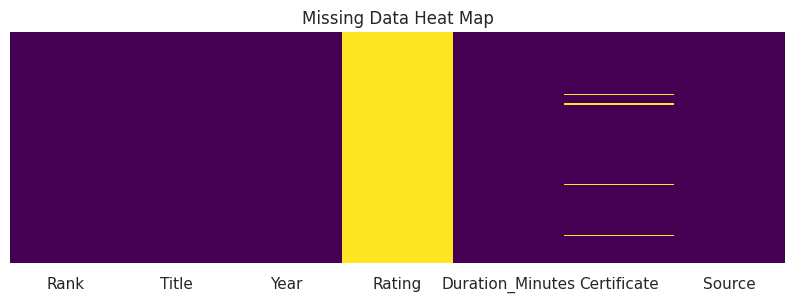

In [5]:
print(df.isnull().sum())
plt.figure(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heat Map')
plt.show()

In [6]:
# Remove the Rating column
df = df.drop('Rating',axis=1)

In [7]:
# Show the rows where the Certificate is null
filas_con_nulos = df[df['Certificate'].isnull()]
display(filas_con_nulos.head())

,Rank,Title,Year,Duration_Minutes,Certificate,Source
68,69,12th Fail,2023,147,NaN,IMDb Top 250
77,78,Your Name.,2016,106,NaN,IMDb Top 250
78,79,Das Boot,1981,149,NaN,IMDb Top 250
165,166,The Chaos Class Failed the Class,1975,95,NaN,IMDb Top 250
220,221,Maharaja,2024,141,NaN,IMDb Top 250


In [8]:
df['Certificate'] = df['Certificate'].fillna('Not specified')
no_cert = df[df['Certificate'] == 'Not specified']
print(no_cert)

     Rank                             Title  Year  Duration_Minutes  \
68     69                         12th Fail  2023               147   
77     78                        Your Name.  2016               106   
78     79                          Das Boot  1981               149   
165   166  The Chaos Class Failed the Class  1975                95   
220   221                          Maharaja  2024               141   

       Certificate        Source  
68   Not specified  IMDb Top 250  
77   Not specified  IMDb Top 250  
78   Not specified  IMDb Top 250  
165  Not specified  IMDb Top 250  
220  Not specified  IMDb Top 250  


In [9]:
df.isnull().sum()

Rank                0
Title               0
Year                0
Duration_Minutes    0
Certificate         0
Source              0
dtype: int64

In [10]:
df.describe()

,Rank,Year,Duration_Minutes
count,250.000000,250.000000,250.000000
mean,125.500000,1988.620000,131.516000
std,72.312977,25.552442,35.747128
min,1.000000,1921.000000,45.000000
25%,63.250000,1973.000000,108.250000
50%,125.500000,1995.000000,127.500000
75%,187.750000,2009.000000,147.750000
max,250.000000,2025.000000,374.000000


<div style="
    background: #F7A80A;
    padding: 18px 22px;
    border-radius: 12px;
    margin: 22px 0;
">
    <h2 style="
        color: #ffffff;
        margin: 0;
        font-size: 22px;
        font-weight: 600;
    ">
        🔎 Statistical Analysis
    </h2>
    <p style="
        color: #f2f2f2;
        margin-top: 8px;
        font-size: 15px;
        line-height: 1.5;
    "> <strong> The following questions are to be answered: </strong> <br>
        <strong> 1. How many movies are there per decade? </strong> <br>
        <strong> 2. Has the running time changed over the years?</strong> <br>
        <strong> 3. Distribution of Certificates </strong> <br>
        <strong> 4. Ranking vs. Decades (Who dominates the top spots?)</strong> <br>
        <strong> 5. Which classification is the most successful?</strong> <br>
        <strong> 6. Correlation Matrix</strong> <br>
    </p>
</div>


Decade
1920     6
1930     6
1940    11
1950    21
1960    16
1970    19
1980    26
1990    39
2000    47
2010    45
2020    14
Name: count, dtype: int64


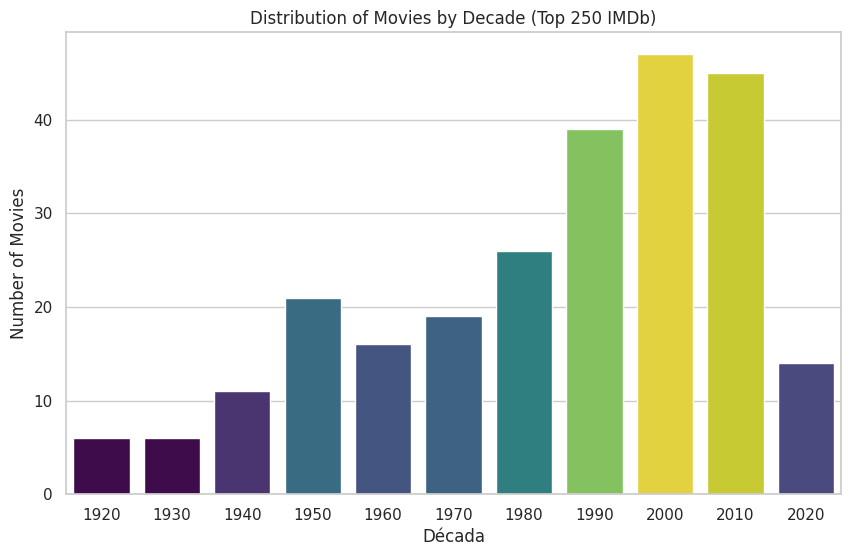

In [11]:
# 1. How many movies are there per decade?
df['Decade'] = (df['Year'] // 10) * 10
print(df['Decade'].value_counts().sort_index())

plt.figure(figsize=(10, 6))
sns.barplot(
    x=df['Decade'].value_counts().sort_index().index, 
    y=df['Decade'].value_counts().sort_index().values, 
    palette="viridis",
    hue=df['Decade'].value_counts().sort_index().values,  # Asignas la misma variable al color
    legend=False  )
plt.title('Distribution of Movies by Decade (Top 250 IMDb)')
plt.xlabel('Década')
plt.ylabel('Number of Movies')
plt.show()

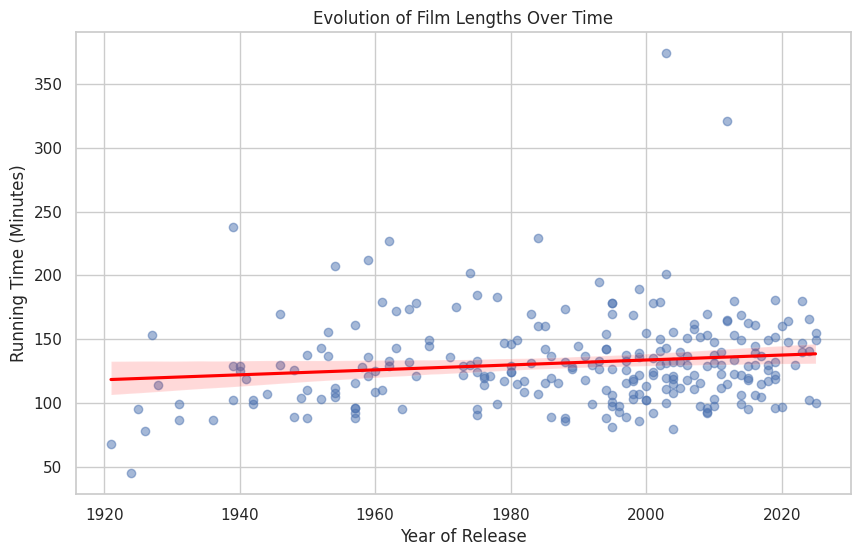

The average running time is: 131.516 minutes


In [12]:
#2 Has the running time changed over the years?
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Year', y='Duration_Minutes', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Evolution of Film Lengths Over Time')
plt.xlabel('Year of Release')
plt.ylabel('Running Time (Minutes)')
plt.show()
print(f"The average running time is: {df['Duration_Minutes'].mean()} minutes")

    Decade  Duration_Minutes
0     1920         92.166667
1     1930        123.666667
2     1940        118.181818
3     1950        126.333333
4     1960        145.062500
5     1970        133.894737
6     1980        131.730769
7     1990        126.820513
8     2000        134.170213
9     2010        135.777778
10    2020        141.357143


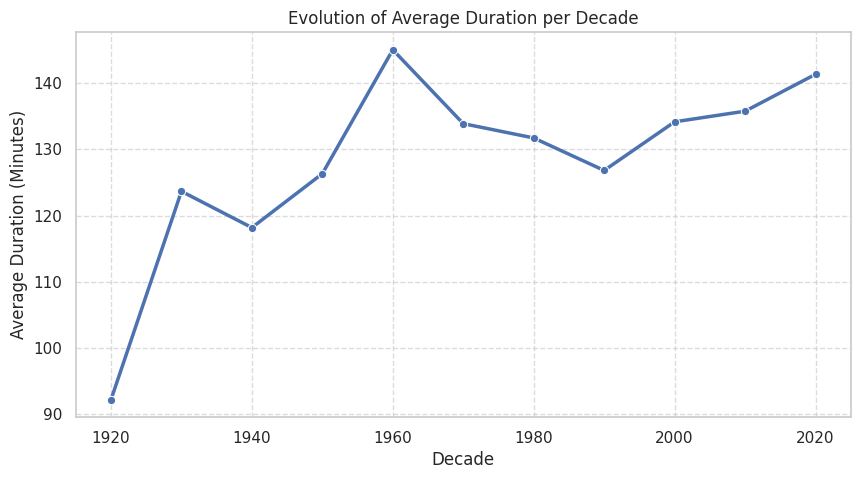

In [13]:
duration_per_decade = df.groupby('Decade')['Duration_Minutes'].mean().reset_index()
print(duration_per_decade)

plt.figure(figsize=(10, 5))
sns.lineplot(data=duration_per_decade, x='Decade', y='Duration_Minutes', marker='o', linewidth=2.5)
plt.title('Evolution of Average Duration per Decade')
plt.xlabel('Decade')
plt.ylabel('Average Duration (Minutes)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

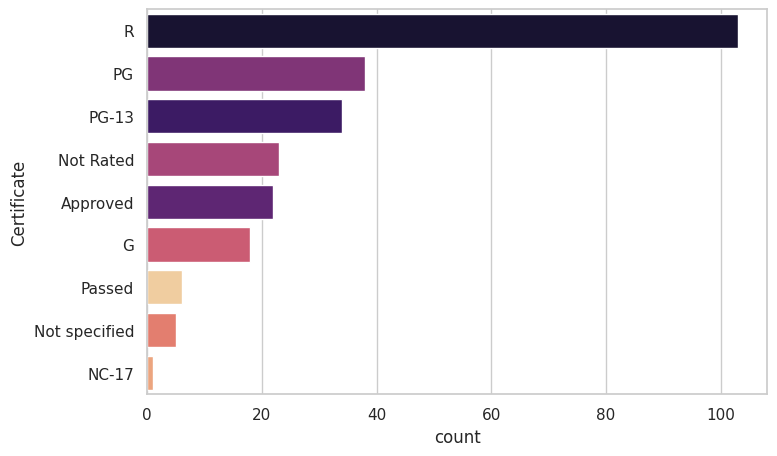

Certificate
R                103
PG                38
PG-13             34
Not Rated         23
Approved          22
G                 18
Passed             6
Not specified      5
NC-17              1
Name: count, dtype: int64


In [14]:
#3 Distribution of Certificates
plt.figure(figsize=(8, 5))
order = df['Certificate'].value_counts().index
sns.countplot(
    data=df, 
    y='Certificate', 
    order=order, 
    palette="magma", 
    hue='Certificate',  
    legend=False        
)
plt.show()
print(df['Certificate'].value_counts())

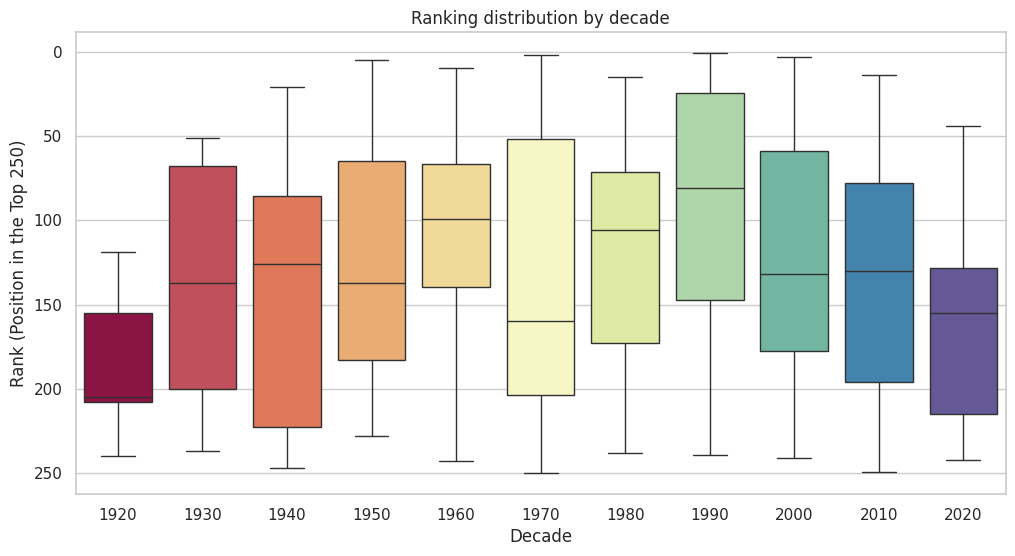

        count        mean        std    min     25%    50%     75%    max
Decade                                                                   
1990     39.0   92.307692  73.226093    1.0   24.50   81.0  147.50  239.0
1960     16.0  109.250000  64.661684   10.0   66.50   99.5  139.50  243.0
1980     26.0  117.846154  64.472439   15.0   71.50  105.5  172.50  238.0
2000     47.0  122.957447  71.656778    3.0   59.00  132.0  177.50  241.0
1950     21.0  129.571429  68.922109    5.0   65.00  137.0  183.00  228.0
1970     19.0  134.210526  84.756238    2.0   52.00  160.0  203.50  250.0
1930      6.0  138.000000  79.337255   51.0   67.75  137.0  200.25  237.0
2010     45.0  138.555556  69.155476   14.0   78.00  130.0  196.00  249.0
1940     11.0  142.272727  81.946435   21.0   85.50  126.0  222.50  247.0
2020     14.0  154.928571  64.857790   44.0  128.50  155.0  215.00  242.0
1920      6.0  186.000000  46.536008  119.0  155.25  204.5  208.00  240.0

min: It's the highest-ranking film of

In [15]:
#4 Ranking vs. Decades (Who dominates the top spots?)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Decade', y='Rank', palette="Spectral",hue='Decade',legend=False)
plt.title('Ranking distribution by decade')
plt.xlabel('Decade')
plt.ylabel('Rank (Position in the Top 250)')
# We inverted the Y-axis because Rank 1 is the best
plt.gca().invert_yaxis() 
plt.show()

ranking_stats = df.groupby('Decade')['Rank'].describe()
print(ranking_stats.sort_values(by='mean'))

print(f"""
min: It's the highest-ranking film of that decade.
max: It's the lowest-ranking film of that decade within the Top 250.""")




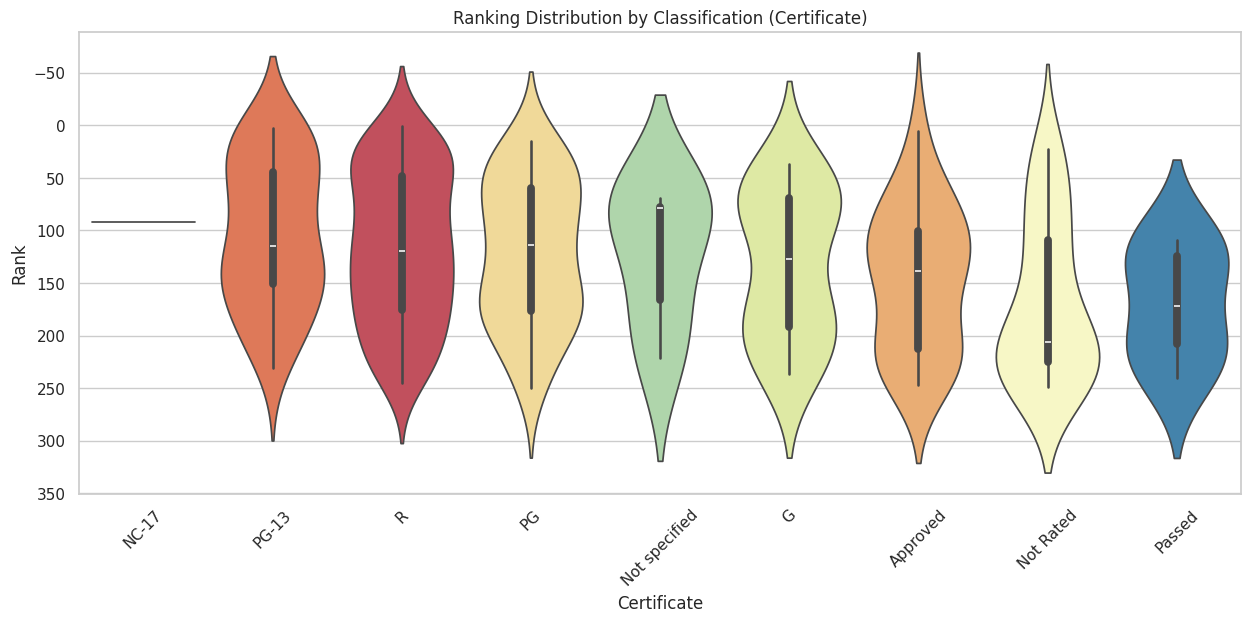

In [16]:
#5 Which classification is the most successful?
plt.figure(figsize=(15, 6))
cert_order = df.groupby('Certificate')['Rank'].mean().sort_values().index

sns.violinplot(data=df, x='Certificate', y='Rank', order=cert_order, palette="Spectral",hue='Certificate',legend=False)
plt.title('Ranking Distribution by Classification (Certificate)')
plt.xlabel('Certificate')
plt.ylabel('Rank')
plt.gca().invert_yaxis()
plt.xticks(rotation=45)
plt.show()

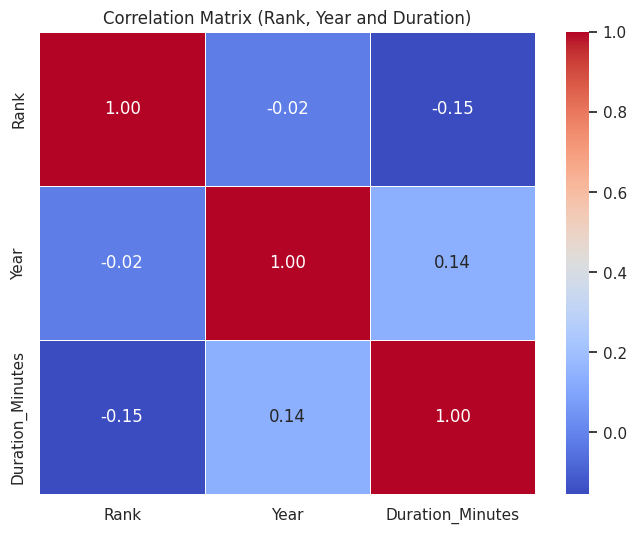

In [17]:
#6 Correlation Matrix
plt.figure(figsize=(8, 6))
# Solo seleccionamos columnas numéricas
numeric_cols = df[['Rank', 'Year', 'Duration_Minutes']]
correlation_matrix = numeric_cols.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (Rank, Year and Duration)')
plt.show()

<div style="
    background: #F7A80A;
    padding: 18px 22px;
    border-radius: 12px;
    margin: 22px 0;
">
    <h2 style="
        color: #ffffff;
        margin: 0;
        font-size: 22px;
        font-weight: 600;
    ">
        📌 Conclusion
    </h2>
</div>

**1. Temporal Hegemony**

The period from 2000 to 2020 stands out as the "Golden Age," accounting for a total of 92 titles in the ranking. A rising trend in movie duration is observed as we move toward the present day, according to the temporal regression analysis.

**2. The "Ideal" Movie Duration**

After analyzing the top 250 movies, the historical average duration is approximately 131.52 minutes. The data shows a high concentration between 134 and 141 minutes, suggesting that long-form narratives resonate more with users compared to shorter productions under 126 minutes.

**3. Impact of Certification and Ranking**

The certification analysis reveals that R-rated movies are not only the most frequent but also tend to hold higher positions in the ranking. This indicates that adult-oriented content receives better critical reception on the platform.

**4. Correlation Findings**

The correlation matrix shows a coefficient of -0.2 between Year and Rank. This weak negative correlation suggests there is no significant "nostalgia bias"; instead, there is a slight tendency for newer films to occupy top spots. Furthermore, the correlation between duration and rank is -0.15 (low), confirming that a film's length is not a direct predictor of its ranking success.

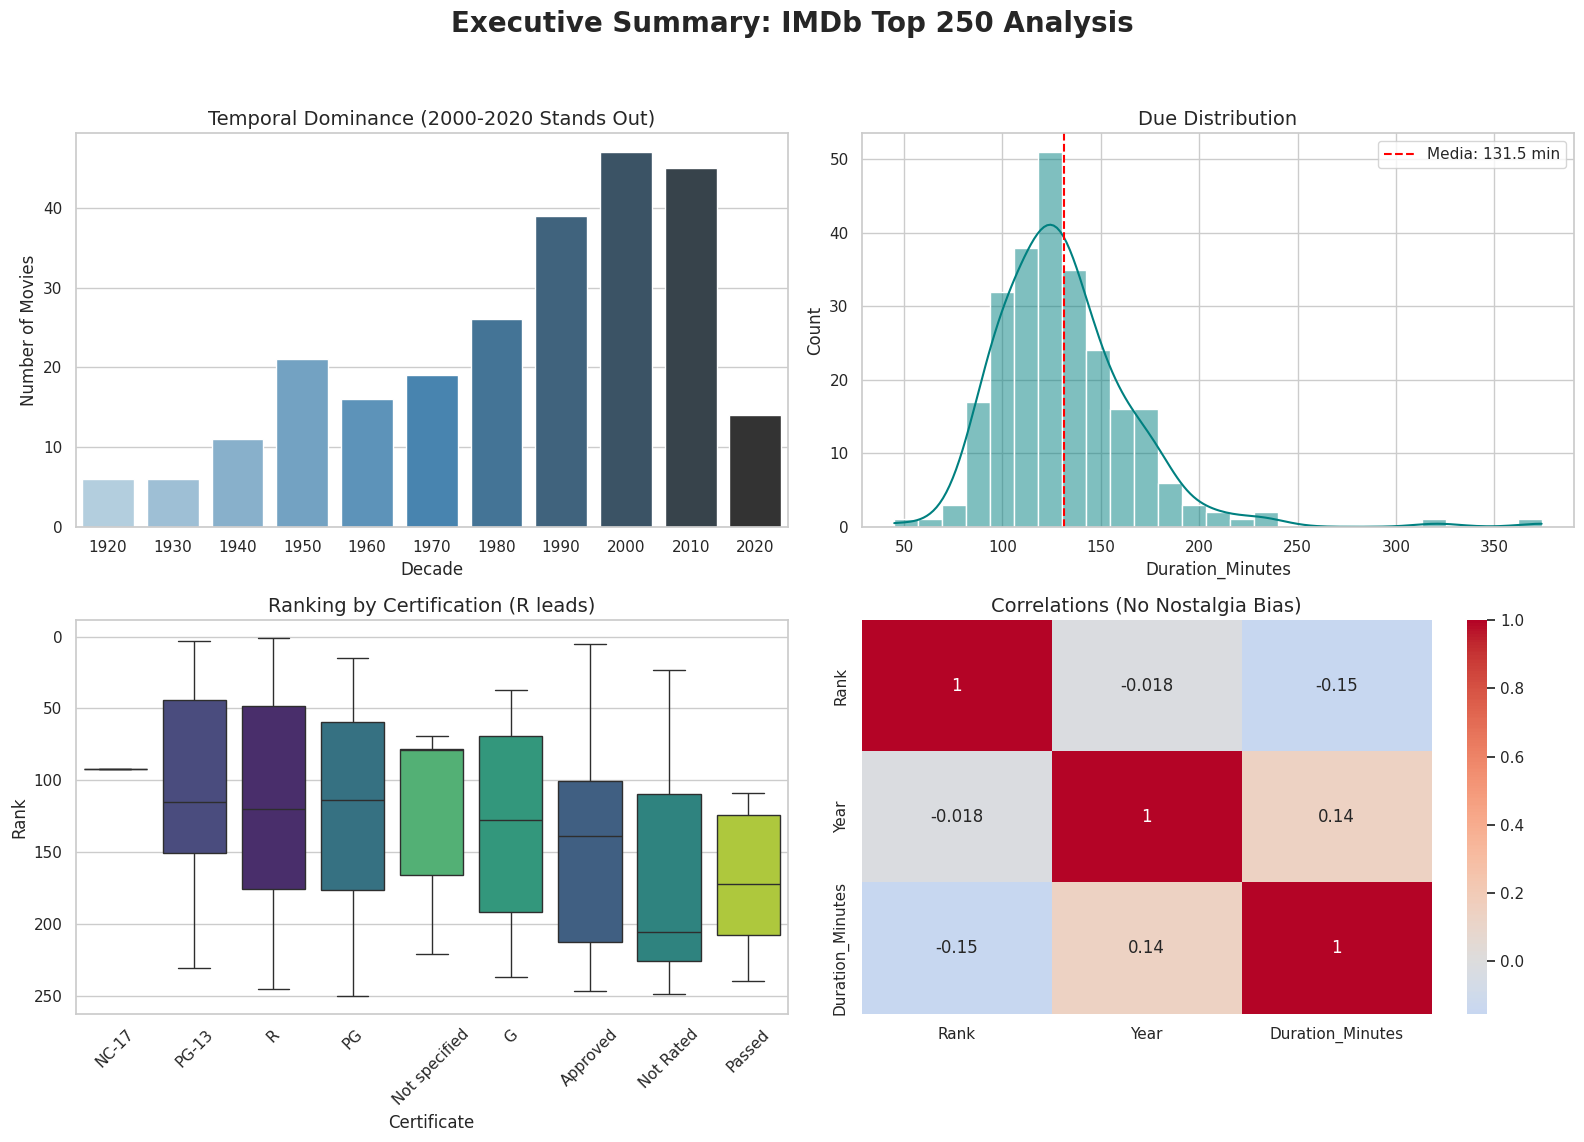

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Executive Summary: IMDb Top 250 Analysis', fontsize=20, fontweight='bold')

golden_age = df['Decade'].value_counts().sort_index()
sns.barplot(ax=axes[0, 0], x=golden_age.index, y=golden_age.values, palette="Blues_d",hue=golden_age.index,legend=False)
axes[0, 0].set_title('Temporal Dominance (2000-2020 Stands Out)', fontsize=14)
axes[0, 0].set_ylabel('Number of Movies')

sns.histplot(ax=axes[0, 1], data=df, x='Duration_Minutes', kde=True, color='teal')
axes[0, 1].axvline(131.52, color='red', linestyle='--', label='Media: 131.5 min')
axes[0, 1].set_title('Due Distribution', fontsize=14)
axes[0, 1].legend()

cert_order = df.groupby('Certificate')['Rank'].mean().sort_values().index
sns.boxplot(ax=axes[1, 0], data=df, x='Certificate', y='Rank', order=cert_order, palette="viridis",hue='Certificate',legend=False)
axes[1, 0].set_title('Ranking by Certification (R leads)', fontsize=14)
axes[1, 0].invert_yaxis() # Recordar que Rank 1 es lo mejor
axes[1, 0].tick_params(axis='x', rotation=45)

sns.heatmap(ax=axes[1, 1], data=correlation_matrix, annot=True, cmap='coolwarm', center=0)
axes[1, 1].set_title('Correlations (No Nostalgia Bias)', fontsize=14)

# Ajustar espacio entre gráficos
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**1. Hegemonía Temporal**

El periodo comprendido entre 2000 y 2020 se consolida como la "Época Dorada" con un total de 92 títulos en el ranking. Se detecta una tendencia ascendente en la duración de las películas conforme avanzamos hacia la actualidad, según lo observado en el análisis de regresión temporal.

**2. El duración de la Película "Ideal"**

Tras analizar las 250 películas mejor puntuadas, se observa que la duración promedio histórica se sitúa en torno a los 131.52 minutos. Los gráficos muestran una alta concentración entre los 134 y 141 minutos, lo que sugiere que las narrativas extensas tienen una mayor presencia en la apreciación de los usuarios frente a producciones de menos de 126 minutos.

**3. Impacto de la Clasificación y el Ranking**
El análisis de certificados revela que las películas con clasificación R no solo son las más frecuentes, sino que tienden a ocupar posiciones superiores en el escalafón. Esto indica que el contenido orientado a adultos tiene una mejor recepción crítica en la plataforma.

**4. Hallazgos de Correlación**
La matriz de correlación arroja un coeficiente de -0.2 entre el Año y el Ranking; al ser un valor negativo cercano a cero, sugiere que no existe un sesgo de nostalgia, sino una ligera inclinación hacia títulos recientes. Asimismo, la correlación entre duración y ranking es de -0.15 (baja), confirmando que la extensión de un filme no es un predictor directo de su éxito en el Top.